# Phase 3 - Analyse & Visualise

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/cleaned/cleaned_titanic.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (891, 8)
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  65.6344        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


We load the cleaned Titanic dataset from Phase 1. It has 891 rows and 8 columns. Sex and Embarked are still text, which is useful for readable chart labels. Fare outliers have already been clipped at 65.63.

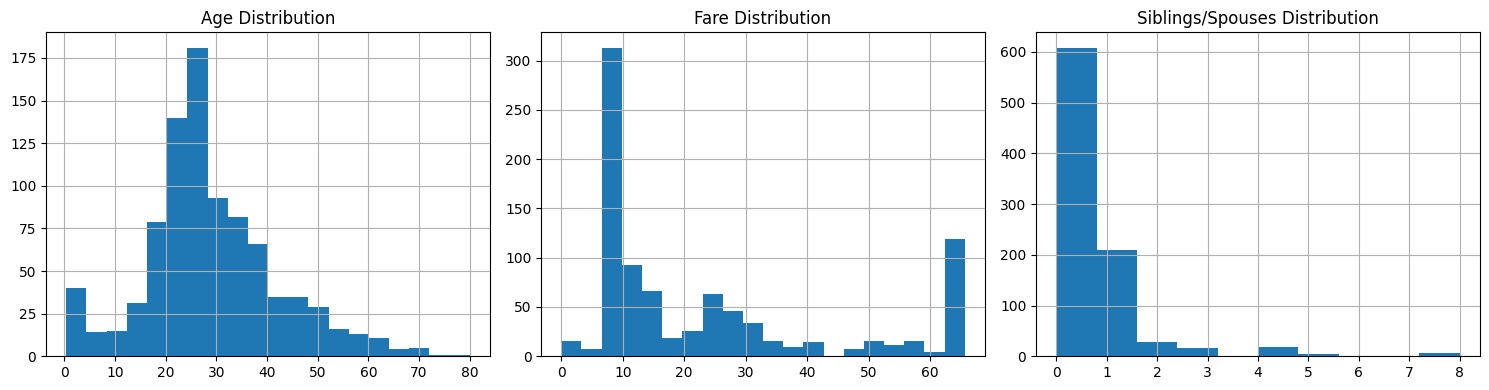

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["Age"].hist(bins=20, ax=axes[0])
axes[0].set_title("Age Distribution")

df["Fare"].hist(bins=20, ax=axes[1])
axes[1].set_title("Fare Distribution")

df["SibSp"].hist(bins=10, ax=axes[2])
axes[2].set_title("Siblings/Spouses Distribution")

plt.tight_layout()
plt.show()

**Age:** Most passengers are between 20-40 years old. The shape is roughly bell-shaped but slightly right-skewed — meaning there are more young adults than elderly passengers.

**Fare:** Almost everyone paid a low fare, but a small number paid higher fares (up to the clipped limit of ~65). This is called right-skewed — the long tail goes to the right. This makes sense because most passengers were 3rd class.

**Siblings/Spouses (SibSp):** Most passengers travelled alone (0 siblings/spouses). Very few had 4 or more. The data drops off fast after 0.

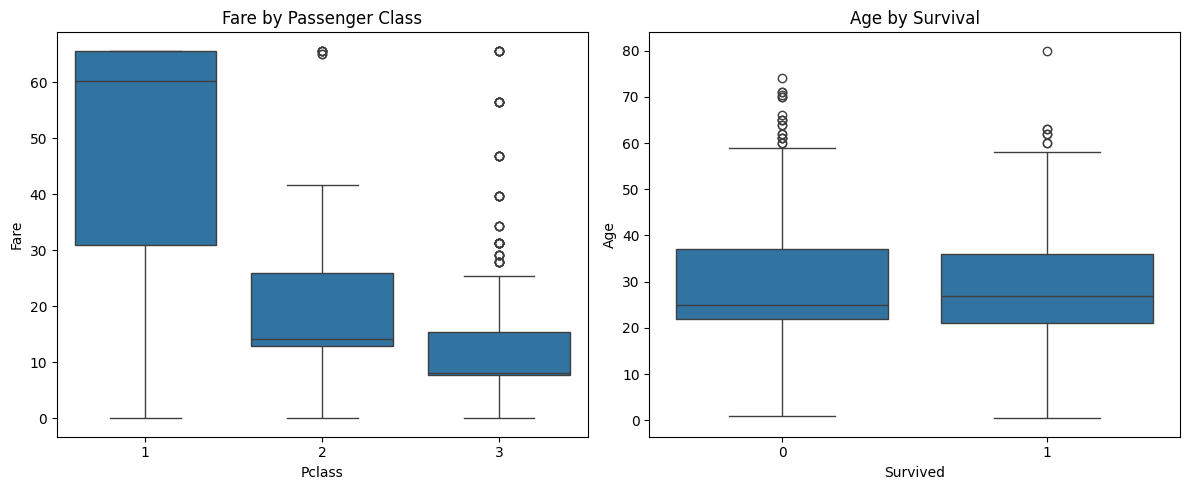

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="Pclass", y="Fare", data=df, ax=axes[0])
axes[0].set_title("Fare by Passenger Class")

sns.boxplot(x="Survived", y="Age", data=df, ax=axes[1])
axes[1].set_title("Age by Survival")

plt.tight_layout()
plt.show()

## What I See in the Boxplots

**Fare by Passenger Class:**
First class passengers paid much more than second and third class. The box for 1st class is higher up on the chart, which means their fares were generally more expensive. Third class fares were very low and tightly packed together — most people paid a similar small amount.

**Age by Survival:**
The age distribution looks similar between survivors (1) and non-survivors (0) — the boxes overlap a lot. This means age alone was not a strong predictor of survival. However, the median age of survivors is slightly lower, which could suggest younger passengers had a slightly better chance. The key takeaway is that other factors like class and sex probably mattered more than age.

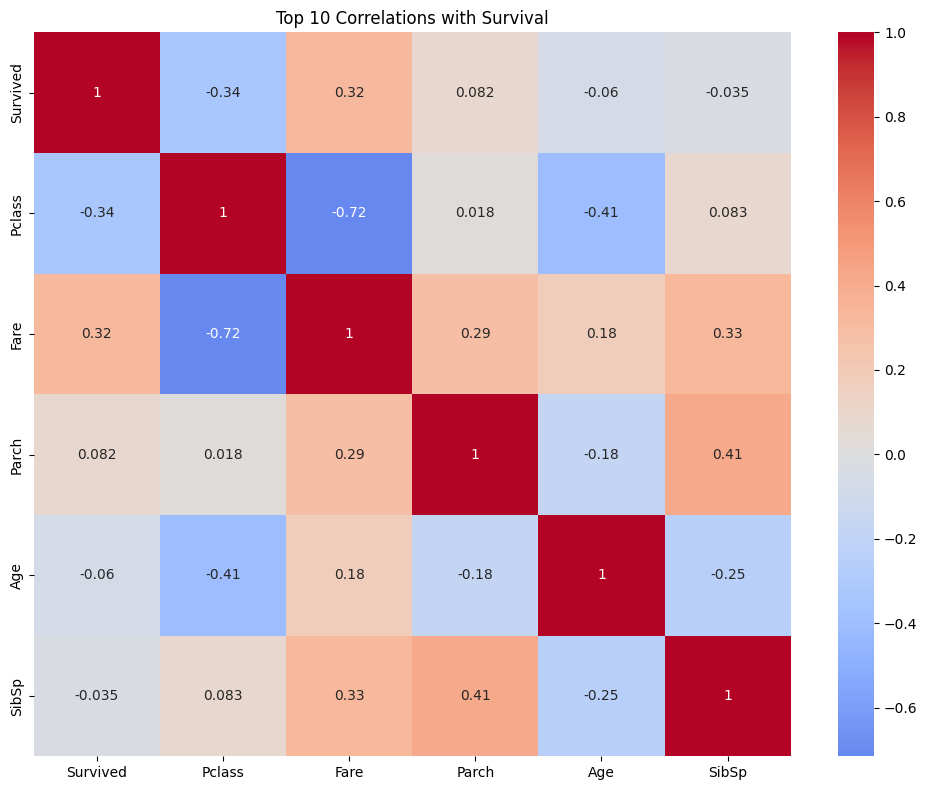

In [4]:
corr = df.select_dtypes(include=[np.number]).corr()
top10 = corr["Survived"].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top10].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Top 10 Correlations with Survival")
plt.tight_layout()
plt.show()

## What I See in the Heatmap

The heatmap shows how strongly each numeric feature is related to survival. The numbers go from -1 to 1:
- Close to **1** = they go up together (positive relationship)
- Close to **-1** = one goes up while the other goes down (opposite relationship)
- Close to **0** = no real connection

The strongest relationships I can see:
- **Fare** has a positive correlation with survival — passengers who paid more were more likely to survive (probably because they were in higher class with better access to lifeboats)
- **Pclass** has a negative correlation with survival — higher class number (3rd class) means lower survival rate
- **SibSp** and **Parch** show small correlations — family size had a minor effect on survival

Gender is also very important but Sex and Embarked are stored as text so they do not appear in this numeric heatmap — they show up clearly in the groupby analysis instead.

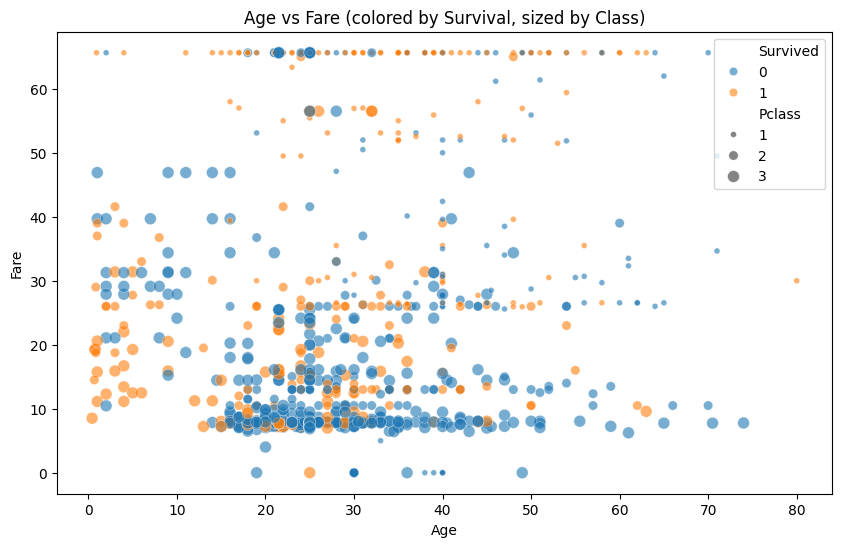

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Age", y="Fare", hue="Survived", size="Pclass",
                data=df, alpha=0.6)
plt.title("Age vs Fare (colored by Survival, sized by Class)")
plt.show()

## What I See in the Scatter Plot

Each dot is one passenger. The position shows their age (left-right) and fare (up-down). The color shows if they survived — orange for yes, blue for no.

What I notice:
- Most of the high-fare passengers (dots near the top) are orange — they survived. This confirms that richer passengers had better survival rates.
- The dots are very dense at the bottom — most passengers paid low fares regardless of age.
- There is no clear age pattern — both young and old passengers are scattered across all fare levels.
- The size of the dot represents their class — bigger dots are 1st class, smaller are 3rd class.

The main story here is that fare (and by extension, class) is a much stronger survival signal than age.

Survival rate by class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by sex:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


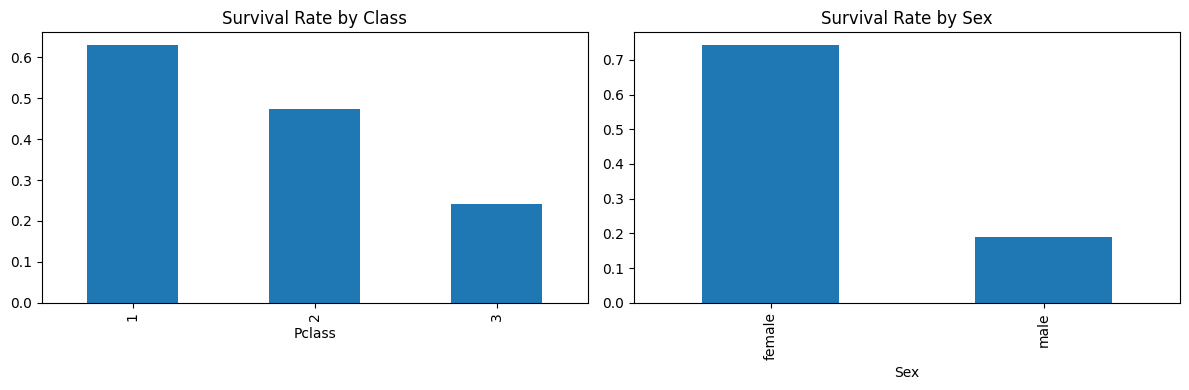

In [6]:
# Survival rate by class
survival_by_class = df.groupby("Pclass")["Survived"].mean()
print("Survival rate by class:\n", survival_by_class)

# Survival rate by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
print("\nSurvival rate by sex:\n", survival_by_sex)

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
survival_by_class.plot(kind="bar", ax=axes[0], title="Survival Rate by Class")
survival_by_sex.plot(kind="bar", ax=axes[1], title="Survival Rate by Sex")
plt.tight_layout()
plt.show()

## What I See in the Groupby Summary

**Survival rate by class:**
- 1st class: ~63% survived
- 2nd class: ~47% survived
- 3rd class: ~24% survived

This is a huge difference. A 1st class passenger was nearly 3 times more likely to survive than a 3rd class passenger. This is probably because 1st class cabins were on upper decks, closer to the lifeboats, and crew likely prioritised them.

**Survival rate by sex:**
- Female: ~74% survived
- Male: ~19% survived

This is the biggest gap in the whole dataset. Women were nearly 4 times more likely to survive than men. This is consistent with the "women and children first" evacuation policy that was followed during the Titanic disaster.

**Overall takeaway:** The two most important factors for survival on the Titanic were your gender and your ticket class. Being a woman in 1st class gave you the best chance of surviving.

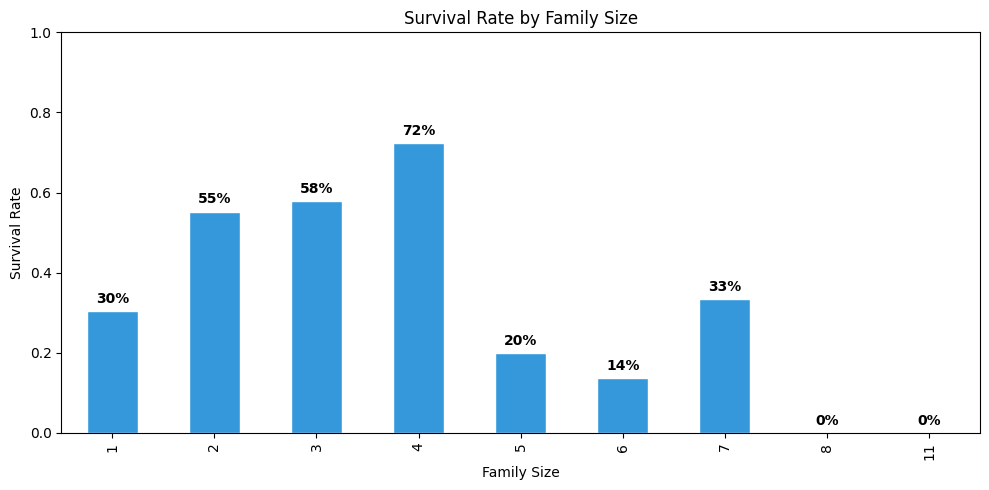

In [7]:
# Survival rate by family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
survival_by_family = df.groupby('FamilySize')['Survived'].mean()

plt.figure(figsize=(10, 5))
survival_by_family.plot(kind='bar', color='#3498db', edgecolor='white')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
for i, v in enumerate(survival_by_family.values):
    plt.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## What I See in Family Size Analysis

Family size has a clear non-linear effect on survival:
- **Solo travelers** (size 1) had a low survival rate — no one to help them
- **Small families** (size 2-4) had the highest survival rates — they could help each other reach lifeboats
- **Large families** (size 5+) had very low survival rates — too many people to coordinate during the chaos

This is an interesting finding because it shows that being with family helped up to a point, but very large groups became a disadvantage. This is why FamilySize is a useful engineered feature in Phase 2.

---

## Dashboard — Key Findings in One View

All 4 most important charts combined into a single figure.

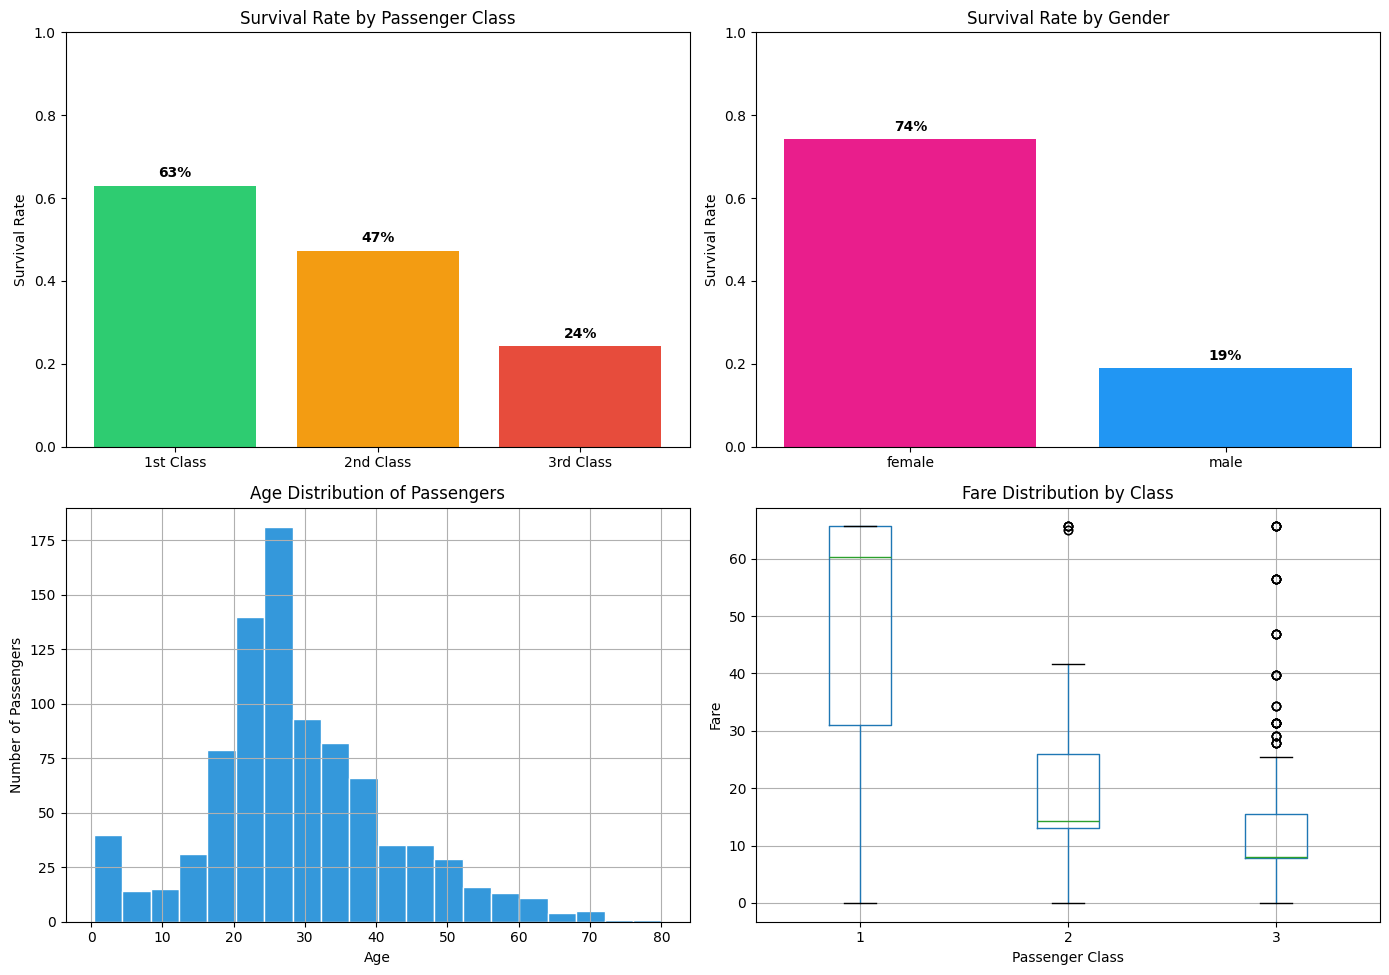

Dashboard saved as dashboard.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic Survival — Key Findings Dashboard", fontsize=16, fontweight="bold")

# Chart 1: Survival rate by class
survival_by_class = df.groupby("Pclass")["Survived"].mean()
axes[0, 0].bar(["1st Class", "2nd Class", "3rd Class"], survival_by_class.values,
               color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[0, 0].set_title("Survival Rate by Passenger Class")
axes[0, 0].set_ylabel("Survival Rate")
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(survival_by_class.values):
    axes[0, 0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Chart 2: Survival rate by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
axes[0, 1].bar(survival_by_sex.index, survival_by_sex.values,
               color=["#e91e8c", "#2196f3"])
axes[0, 1].set_title("Survival Rate by Gender")
axes[0, 1].set_ylabel("Survival Rate")
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(survival_by_sex.values):
    axes[0, 1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Chart 3: Age distribution
df["Age"].hist(bins=20, ax=axes[1, 0], color="#3498db", edgecolor="white")
axes[1, 0].set_title("Age Distribution of Passengers")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Number of Passengers")

# Chart 4: Fare by class boxplot
df.boxplot(column="Fare", by="Pclass", ax=axes[1, 1])
axes[1, 1].set_title("Fare Distribution by Class")
axes[1, 1].set_xlabel("Passenger Class")
axes[1, 1].set_ylabel("Fare")
plt.suptitle("")  # remove default boxplot title

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as dashboard.png")

The dashboard combines the 4 most important findings:
1. **Class matters** — 1st class survived 3x more than 3rd class
2. **Gender matters** — women survived 4x more than men
3. **Age is roughly normal** — most passengers were 20-40
4. **Fare reflects class** — 1st class paid far more, 3rd class fares were clustered at the bottom